# V&V for ML Systems: A Systems Engineering Perspective

**Audience:** SE professionals who know requirements engineering, FMEA/HARA, and traceability — but want to see how these apply to ML components.

**What you'll learn:**
1. How traditional V&V concepts map to ML systems
2. Formalizing requirements with INCOSE GtWR quality gates
3. HARA, ODD, and I/O contracts for ML components
4. Standards compliance mapping (ISO/PAS 8800, ISO 21448, EU AI Act)
5. Automated traceability and compliance documentation

**Time:** ~35 minutes

---

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from vnvspec import (
    Spec, Requirement, Evidence, Hazard, ODD,
    IOContract, Invariant, TraceLink,
    build_trace_graph, coverage_report,
)
from vnvspec.core.assessment import Report
from vnvspec.registries import load, list_available
from vnvspec.exporters import (
    export_html, export_markdown, export_gsn_mermaid,
    export_annex_iv, export_json,
)
from vnvspec.runners.pytest_gen import generate_pytest
from vnvspec.runners.hypothesis_gen import generate_hypothesis

from _helpers import (
    display_requirements_table, display_violations_table,
    display_evidence_table, display_report_summary,
    plot_violations_by_rule, plot_evidence_verdicts,
    plot_coverage, plot_trace_graph,
    display_registry_sample, display_mermaid,
)
print("All imports ready.")

All imports ready.


## 2. Traditional V&V vs. ML V&V

| SE Concept | Traditional | ML Equivalent |
|-----------|------------|---------------|
| **Requirements** | "The brake shall engage within 200 ms" | "The classifier shall produce probabilities in [0, 1]" |
| **Design spec** | Circuit schematic, state machine | Model architecture, hyperparameters, training config |
| **Verification** | Unit test, integration test, static analysis | Model evaluation, property testing, formal invariants |
| **Validation** | Acceptance testing with stakeholders | ODD coverage, scenario-based testing, field trials |
| **HARA** | Hardware FMEA, FTA | ML-specific hazard analysis (data quality, distribution shift, adversarial) |
| **Traceability** | Requirements → tests → code | Requirements → model behavior → evidence → standards |

The key difference: **ML systems have stochastic behavior**. You can't prove correctness — you collect *evidence* and manage *risk*.

## 3. Formalizing Requirements for an ML Component

Let's spec a perception classifier for an autonomous vehicle:

In [2]:
# A real-ish set of requirements for an AV perception classifier
requirements = [
    Requirement(
        id="REQ-FUNC-001",
        statement="The classifier shall assign exactly one label from the set {vehicle, pedestrian, cyclist, background} to each detected object.",
        rationale="Mutual exclusivity required by the tracking module.",
        verification_method="test",
        acceptance_criteria=["Output argmax yields exactly one label per detection."],
        standards={"iso_pas_8800": ["6.3.1"], "iso_21448": ["5.2"]},
        priority="high",
    ),
    Requirement(
        id="REQ-PERF-001",
        statement="The classifier shall achieve mean average precision above 0.85 on the validation set.",
        rationale="Performance floor derived from SOTIF residual-risk analysis.",
        verification_method="test",
        acceptance_criteria=["mAP >= 0.85 on the held-out validation set."],
        standards={"iso_21448": ["6.3", "10.1"]},
        priority="high",
    ),
    Requirement(
        id="REQ-ROB-001",
        statement="The classifier shall maintain precision above 0.70 under gaussian noise with sigma 0.1.",
        rationale="Sensor noise robustness per ISO/PAS 8800 clause 7.4.",
        verification_method="test",
        acceptance_criteria=["Precision > 0.70 with noise augmentation (sigma=0.1)."],
        standards={"iso_pas_8800": ["7.4"]},
    ),
    Requirement(
        id="REQ-DATA-001",
        statement="The training dataset shall contain at least 1000 samples per class.",
        rationale="Data sufficiency for statistical significance.",
        verification_method="inspection",
        acceptance_criteria=["Dataset class histogram shows >= 1000 per class."],
        standards={"iso_pas_8800": ["6.2.3"], "eu_ai_act": ["Article 10"]},
    ),
    Requirement(
        id="REQ-SAFE-001",
        statement="The classifier shall flag low-confidence predictions below 0.6 threshold.",
        rationale="Safety mechanism: uncertain predictions routed to human operator.",
        verification_method="test",
        acceptance_criteria=["Predictions with max_prob < 0.6 are flagged."],
        standards={"iso_21448": ["7.1"], "ul_4600": ["8.5"]},
        priority="high",
    ),
]

display_requirements_table(requirements)

ID,Statement,Method,Priority
REQ-FUNC-001,"The classifier shall assign exactly one label from the set {vehicle, pedestrian, cyclist, background} to each detected object.",test,high
REQ-PERF-001,The classifier shall achieve mean average precision above 0.85 on the validation set.,test,high
REQ-ROB-001,The classifier shall maintain precision above 0.70 under gaussian noise with sigma 0.1.,test,medium
REQ-DATA-001,The training dataset shall contain at least 1000 samples per class.,inspection,medium
REQ-SAFE-001,The classifier shall flag low-confidence predictions below 0.6 threshold.,test,high


## 4. INCOSE GtWR Quality Gate

Running GtWR quality gate on all requirements...

  REQ-FUNC-001: PASS
  REQ-PERF-001: FAIL (1 issues)
  REQ-ROB-001: FAIL (1 issues)
  REQ-DATA-001: FAIL (1 issues)
  REQ-SAFE-001: FAIL (1 issues)

Total: 4 violations across 5 requirements


Rule,Name,Severity,Message
R6,Unit-bearing,warning,Statement contains numeric(s) ['0.85'] without recognized units. Add units to avoid ambiguity.
R6,Unit-bearing,warning,"Statement contains numeric(s) ['0.70', '0.1'] without recognized units. Add units to avoid ambiguity."
R7,Complete,warning,"Statement lacks a clear subject (e.g., 'The system shall ...')."
R6,Unit-bearing,warning,Statement contains numeric(s) ['0.6'] without recognized units. Add units to avoid ambiguity.


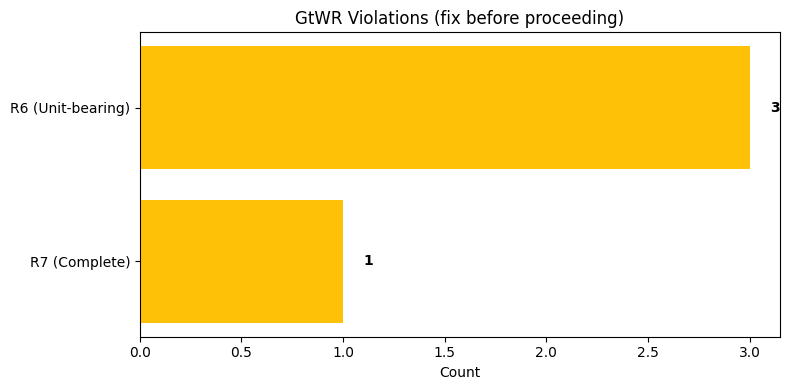

In [3]:
print("Running GtWR quality gate on all requirements...\n")

all_violations = []
for req in requirements:
    v = req.check_quality()
    all_violations.extend(v)
    icon = "PASS" if not v else f"FAIL ({len(v)} issues)"
    print(f"  {req.id}: {icon}")

print(f"\nTotal: {len(all_violations)} violations across {len(requirements)} requirements")

if all_violations:
    display_violations_table(all_violations)
    plot_violations_by_rule(all_violations, "GtWR Violations (fix before proceeding)")

## 5. Input-Output Contracts

An **IOContract** formalizes the interface between your ML component and the rest of the system — like a typed API contract but with runtime-checkable invariants.

In [4]:
contract = IOContract(
    name="perception-classifier-io",
    description="Contract for the AV perception classifier.",
    inputs={
        "image": {"type": "tensor", "shape": [3, 640, 640], "dtype": "float32"},
        "confidence_threshold": {"type": "float", "range": [0.0, 1.0]},
    },
    outputs={
        "labels": {"type": "tensor", "shape": ["N"], "dtype": "int64"},
        "probabilities": {"type": "tensor", "shape": ["N", 4], "dtype": "float32"},
    },
    invariants=[
        Invariant(name="prob_range", description="Probabilities in [0,1]", check_expr="0 <= value <= 1"),
        Invariant(name="prob_sum", description="Probabilities sum to ~1", check_expr="abs(value - 1.0) < 0.01"),
        Invariant(name="label_valid", description="Labels in {0,1,2,3}", check_expr="value in (0, 1, 2, 3)"),
    ],
)

# Check invariants with sample values
sample_results = contract.check_invariants({
    "prob_range": 0.85,
    "prob_sum": 0.9999,
    "label_valid": 2,
})
print("Invariant checks:", sample_results)

Invariant checks: {'prob_range': True, 'prob_sum': False, 'label_valid': True}


## 6. HARA and Operational Design Domain

In [5]:
# Hazard Analysis and Risk Assessment
hazards = [
    Hazard(
        id="HAZ-001",
        description="Misclassification of pedestrian as background leads to collision.",
        severity="S3", exposure="E4", controllability="C2", asil="D",
        mitigations=["REQ-FUNC-001", "REQ-PERF-001", "REQ-SAFE-001"],
    ),
    Hazard(
        id="HAZ-002",
        description="Sensor noise degrades classification below safe threshold.",
        severity="S2", exposure="E3", controllability="C2", asil="B",
        mitigations=["REQ-ROB-001"],
    ),
]

# Operational Design Domain
odd = ODD(
    name="urban-driving-odd",
    dimensions={
        "speed_range_kmh": [0, 60],
        "weather": ["clear", "overcast", "light_rain"],
        "lighting": ["day", "dusk"],
        "road_type": ["urban_street", "parking_lot"],
        "traffic_density": ["low", "medium", "high"],
    },
    source_ontology="bsi_pas_1883",
)

print(f"ODD: {odd.name}")
print(f"Dimensions: {odd.dimension_names()}")
print(f"\nHazards: {len(hazards)}")
for h in hazards:
    print(f"  {h.id} [{h.asil}]: {h.description[:60]}...")

ODD: urban-driving-odd
Dimensions: ['lighting', 'road_type', 'speed_range_kmh', 'traffic_density', 'weather']

Hazards: 2
  HAZ-001 [D]: Misclassification of pedestrian as background leads to colli...
  HAZ-002 [B]: Sensor noise degrades classification below safe threshold....


## 7. Assembling the Full Spec

In [6]:
spec = Spec(
    name="av-perception-v1",
    version="0.3.0",
    requirements=requirements,
    contracts=[contract],
    odds=[odd],
    hazards=hazards,
)

print(f"Spec: {spec.name} v{spec.version}")
print(f"  Requirements: {len(spec.requirements)}")
print(f"  Contracts:    {len(spec.contracts)}")
print(f"  Hazards:      {len(spec.hazards)}")
print(f"  ODDs:         {len(spec.odds)}")

Spec: av-perception-v1 v0.3.0
  Requirements: 5
  Contracts:    1
  Hazards:      2
  ODDs:         1


## 8. Simulated Evidence Collection

In [7]:
# Simulate test results (in practice, these come from real test runs)
evidence = [
    Evidence(id="EV-FUNC-001", requirement_id="REQ-FUNC-001",
             kind="test", verdict="pass",
             details={"test_suite": "unit_tests", "samples": 5000}),
    Evidence(id="EV-PERF-001", requirement_id="REQ-PERF-001",
             kind="test", verdict="pass",
             details={"mAP": 0.891, "dataset": "val_v3"}),
    Evidence(id="EV-ROB-001", requirement_id="REQ-ROB-001",
             kind="test", verdict="fail",
             details={"precision": 0.63, "sigma": 0.1, "note": "Below 0.70 threshold"}),
    Evidence(id="EV-DATA-001", requirement_id="REQ-DATA-001",
             kind="inspection", verdict="pass",
             details={"min_class_count": 1247, "classes": 4}),
    Evidence(id="EV-SAFE-001", requirement_id="REQ-SAFE-001",
             kind="test", verdict="pass",
             details={"flagged_rate": 0.12, "threshold": 0.6}),
]

display_evidence_table(evidence)

Evidence ID,Requirement,Kind,Verdict,Observed
EV-FUNC-001,REQ-FUNC-001,test,pass,2026-04-17 03:41
EV-PERF-001,REQ-PERF-001,test,pass,2026-04-17 03:41
EV-ROB-001,REQ-ROB-001,test,fail,2026-04-17 03:41
EV-DATA-001,REQ-DATA-001,inspection,pass,2026-04-17 03:41
EV-SAFE-001,REQ-SAFE-001,test,pass,2026-04-17 03:41


## 9. Assessment Report

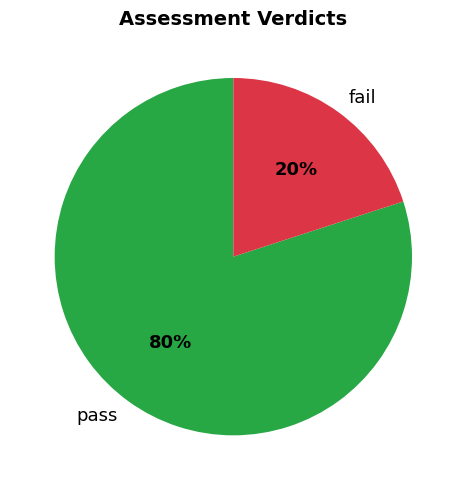

In [8]:
report = Report(
    spec_name=spec.name,
    spec_version=spec.version,
    evidence=evidence,
    summary={"mAP": 0.891, "robustness_precision": 0.63},
)

display_report_summary(report)
plot_evidence_verdicts(report.evidence, "Assessment Verdicts")

## 10. Full Traceability Graph

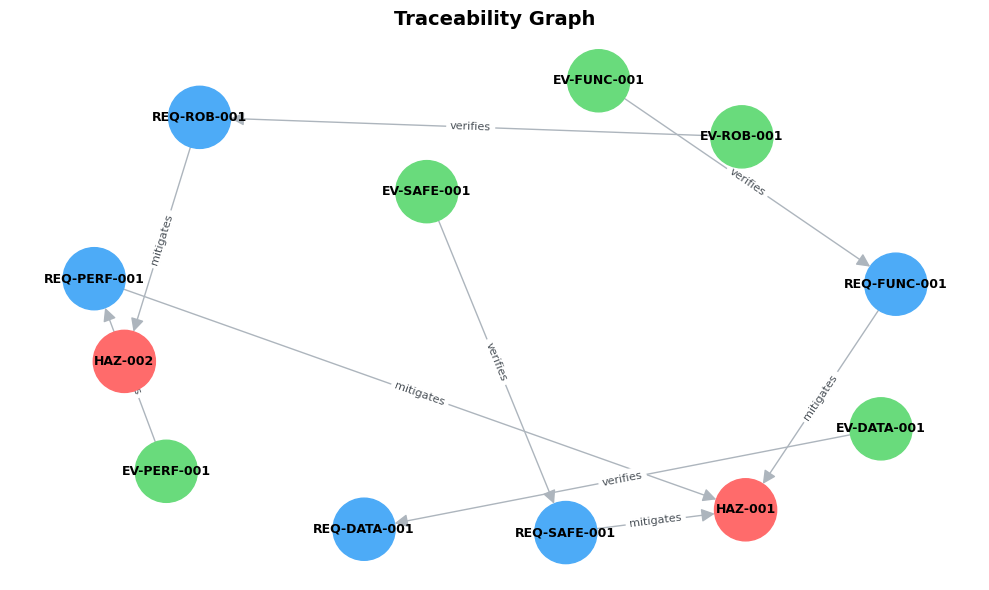

In [9]:
# Build links: evidence -> requirements -> hazards -> standards
links = [
    # Evidence verifies requirements
    TraceLink(source_id="EV-FUNC-001", target_id="REQ-FUNC-001", relation="verifies"),
    TraceLink(source_id="EV-PERF-001", target_id="REQ-PERF-001", relation="verifies"),
    TraceLink(source_id="EV-ROB-001", target_id="REQ-ROB-001", relation="verifies"),
    TraceLink(source_id="EV-DATA-001", target_id="REQ-DATA-001", relation="verifies"),
    TraceLink(source_id="EV-SAFE-001", target_id="REQ-SAFE-001", relation="verifies"),
    # Requirements mitigate hazards
    TraceLink(source_id="REQ-FUNC-001", target_id="HAZ-001", relation="mitigates"),
    TraceLink(source_id="REQ-PERF-001", target_id="HAZ-001", relation="mitigates"),
    TraceLink(source_id="REQ-SAFE-001", target_id="HAZ-001", relation="mitigates"),
    TraceLink(source_id="REQ-ROB-001", target_id="HAZ-002", relation="mitigates"),
]

plot_trace_graph(links)

In [10]:
# Coverage report
graph = build_trace_graph(links)
cov = coverage_report(graph, [r.id for r in spec.requirements])
for req_id, linked in cov.items():
    print(f"{req_id}: {dict(linked)}")

REQ-FUNC-001: {'verifies': ['EV-FUNC-001'], 'mitigates': ['HAZ-001']}
REQ-PERF-001: {'verifies': ['EV-PERF-001'], 'mitigates': ['HAZ-001']}
REQ-ROB-001: {'verifies': ['EV-ROB-001'], 'mitigates': ['HAZ-002']}
REQ-DATA-001: {'verifies': ['EV-DATA-001']}
REQ-SAFE-001: {'verifies': ['EV-SAFE-001'], 'mitigates': ['HAZ-001']}


## 11. Standards Compliance

In [11]:
print("Mapped standards per requirement:\n")
for req in spec.requirements:
    if req.standards:
        for std, clauses in req.standards.items():
            print(f"  {req.id} -> {std}: {clauses}")

Mapped standards per requirement:

  REQ-FUNC-001 -> iso_pas_8800: ['6.3.1']
  REQ-FUNC-001 -> iso_21448: ['5.2']
  REQ-PERF-001 -> iso_21448: ['6.3', '10.1']
  REQ-ROB-001 -> iso_pas_8800: ['7.4']
  REQ-DATA-001 -> iso_pas_8800: ['6.2.3']
  REQ-DATA-001 -> eu_ai_act: ['Article 10']
  REQ-SAFE-001 -> iso_21448: ['7.1']
  REQ-SAFE-001 -> ul_4600: ['8.5']


In [12]:
# Browse ISO/PAS 8800
display_registry_sample("iso_pas_8800", n=6)

Clause,Title,Level,Summary
5,AI safety lifecycle overview,informative,Defines the overall lifecycle for managing safety of AI-based systems in road ve...
5.1,General principles for AI safety,shall,Establishes foundational principles for ensuring AI components in vehicles meet ...
5.2,AI safety plan,shall,Requires creation and maintenance of a safety plan that addresses AI-specific ri...
5.3,Integration with ISO 26262,shall,Describes how AI safety activities integrate with the functional safety lifecycl...
5.4,Integration with ISO 21448 (SOTIF),should,Explains the relationship between AI safety management and SOTIF processes for h...
6,AI safety requirements,informative,Covers derivation and specification of safety requirements that are specific to ...


In [13]:
# EU AI Act Annex IV compliance document
annex_iv = export_annex_iv(report)
print(annex_iv[:1500])
print("\n... (truncated)")

# EU AI Act — Annex IV Technical Documentation

**System**: av-perception-v1 v0.3.0
**Date**: 2026-04-17T03:41:24.380434+00:00

---

## 1. Intended Purpose

System name: av-perception-v1
Version: 0.3.0
Overall verdict: fail

## 2. Design and Development

Total evidence items: 5
Pass: 4 | Fail: 1

Verification activities by kind:

- **inspection**: EV-DATA-001
- **test**: EV-FUNC-001, EV-PERF-001, EV-ROB-001, EV-SAFE-001

## 3. Performance Metrics

- mAP: 0.891
- robustness_precision: 0.63

## 4. Risk Management and V&V Evidence

| ID | Requirement | Kind | Verdict | Observed |
|---|---|---|---|---|
| EV-DATA-001 | REQ-DATA-001 | inspection | pass | 2026-04-17T03:41:24.377906+00:00 |
| EV-FUNC-001 | REQ-FUNC-001 | test | pass | 2026-04-17T03:41:24.377901+00:00 |
| EV-PERF-001 | REQ-PERF-001 | test | pass | 2026-04-17T03:41:24.377904+00:00 |
| EV-ROB-001 | REQ-ROB-001 | test | fail | 2026-04-17T03:41:24.377905+00:00 |
| EV-SAFE-001 | REQ-SAFE-001 | test | pass | 2026-04-17T03:41:24.37790

## 12. Goal Structuring Notation (GSN) Assurance Case

In [14]:
gsn = export_gsn_mermaid(report)
print(gsn)
display_mermaid(gsn)

flowchart TD
    G1["av-perception-v1 v0.3.0: fail"]
    S1["REQ-DATA-001"]
    G1 --> S1
    E_EV_DATA_001["EV-DATA-001: pass"]
    S1 --> E_EV_DATA_001
    S2["REQ-FUNC-001"]
    G1 --> S2
    E_EV_FUNC_001["EV-FUNC-001: pass"]
    S2 --> E_EV_FUNC_001
    S3["REQ-PERF-001"]
    G1 --> S3
    E_EV_PERF_001["EV-PERF-001: pass"]
    S3 --> E_EV_PERF_001
    S4["REQ-ROB-001"]
    G1 --> S4
    E_EV_ROB_001["EV-ROB-001: fail"]
    S4 --> E_EV_ROB_001
    S5["REQ-SAFE-001"]
    G1 --> S5
    E_EV_SAFE_001["EV-SAFE-001: pass"]
    S5 --> E_EV_SAFE_001



## 13. Auto-Generated Test Suites

In [15]:
# Generate pytest file from the spec
pytest_code = generate_pytest(spec)
print("=== Generated pytest file ===\n")
print(pytest_code)

=== Generated pytest file ===

"""Auto-generated pytest tests for spec: av-perception-v1."""

from __future__ import annotations

import pytest

@pytest.mark.parametrize("criterion", ['Output argmax yields exactly one label per detection.'])
def test_req_func_001(criterion: str) -> None:
    """REQ-FUNC-001: The classifier shall assign exactly one label from the set {vehicle, pedestrian, cyclist, background} to each detected object."""
    # TODO: implement verification logic for REQ-FUNC-001
    assert criterion is not None


@pytest.mark.parametrize("criterion", ['mAP >= 0.85 on the held-out validation set.'])
def test_req_perf_001(criterion: str) -> None:
    """REQ-PERF-001: The classifier shall achieve mean average precision above 0.85 on the validation set."""
    # TODO: implement verification logic for REQ-PERF-001
    assert criterion is not None


@pytest.mark.parametrize("criterion", ['Precision > 0.70 with noise augmentation (sigma=0.1).'])
def test_req_rob_001(criterion: s

In [16]:
# Generate hypothesis property tests from the contract
hyp_code = generate_hypothesis(contract)
print("=== Generated hypothesis tests ===\n")
print(hyp_code)

=== Generated hypothesis tests ===

"""Auto-generated hypothesis tests for contract: perception-classifier-io."""

from __future__ import annotations

from hypothesis import given, strategies

@given(value=strategies.floats(min_value=0, max_value=1))
def test_prob_range(value: float) -> None:
    """Probabilities in [0,1]"""
    assert 0 <= value <= 1


@given(value=strategies.from_type(float))
def test_prob_sum(value: float) -> None:
    """Probabilities sum to ~1"""
    assert abs(value - 1.0) < 0.01


@given(value=strategies.from_type(float))
def test_label_valid(value: float) -> None:
    """Labels in {0,1,2,3}"""
    assert value in (0, 1, 2, 3)




## Summary

| SE Artifact | vnvspec API | Output |
|------------|-------------|--------|
| Requirements document | `Spec(requirements=[...])` | Typed, machine-readable spec |
| FMEA / HARA | `Hazard(severity, exposure, ...)` | Hazard registry with ASIL |
| Traceability matrix | `TraceLink` + `build_trace_graph()` | Interactive graph + coverage |
| Test procedures | `generate_pytest(spec)` | Runnable pytest file |
| V&V report | `Report(evidence=[...])` | HTML, Markdown, JSON |
| Compliance doc | `export_annex_iv(report)` | EU AI Act Annex IV draft |
| Assurance case | `export_gsn_mermaid(report)` | GSN diagram (Mermaid) |

**Next:** See Notebook 3 for PyTorch model wrapping and automated assessment.